# **TikTok Project**
**Course 5 - The Nuts and bolts of machine learning**

Recall that you are a data professional at TikTok. Your supervisor was impressed with the work you have done and has requested that you **build a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion**. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 5 End-of-course project: Classifying videos using machine learning**

In this activity, you will practice using machine learning techniques to predict on a binary outcome variable.
<br/>

**The purpose** of this model is to increase response time and system efficiency by automating the initial stages of the claims process.

**The goal** of this model is to predict whether a TikTok video presents a "claim" or presents an "opinion".
<br/>

*This activity has three parts:*

**Part 1:** Ethical considerations
* Consider the ethical implications of the request

* Should the objective of the model be adjusted?

**Part 2:** Feature engineering

* Perform feature selection, extraction, and transformation to prepare the data for modeling

**Part 3:** Modeling

* Build the models, evaluate them, and advise on next steps

Follow the instructions and answer the questions below to complete the activity. Then, you will complete an Executive Summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.



# **Classify videos using machine learning**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**


Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following questions:


1.   **What are you being asked to do? What metric should I use to evaluate success of my business/organizational objective?**

2.   **What are the ethical implications of the model? What are the consequences of your model making errors?**
  *   What is the likely effect of the model when it predicts a false negative (i.e., when the model says a video does not contain a claim and it actually does)?

  *   What is the likely effect of the model when it predicts a false positive (i.e., when the model says a video does contain a claim and it actually does not)?

3.   **How would you proceed?**


==> ENTER YOUR RESPONSES HERE
1. Create a random forest mode and send an executive summary of my random forest model and results. To evaluate the success of the organizational objective, I will use accuracy, recall, precision, f1 score, and f-beta score as metrics. 

2. Ethical Implications - Bias, fairness, transparency, privacy, overconfidence 

When it predicts a false negative, we overlook the claim video, which might spread misinformation in public, so this leads to potential harm for users and reputation of the company. 
When it predicts a false positive, In this case, we predicted an ‘opinion’ video as a ‘claim’ video, so we might use extra resources to recheck the video. 

3. EDA -> Feature engineering -> Split the dataset( Train/Validate/Test = 60/20/20) -> Create a tree-based model and fit the training data -> Use recall or f-beta score to decide the best hyperparameters -> Choose the best model by using the validation dataset -> Use test data to get final results -> Create an executive summary


**Modeling workflow and model selection process**

Previous work with this data has revealed that there are ~20,000 videos in the sample. This is sufficient to conduct a rigorous model validation workflow, broken into the following steps:

1. Split the data into train/validation/test sets (60/20/20)
2. Fit models and tune hyperparameters on the training set
3. Perform final model selection on the validation set
4. Assess the champion model's performance on the test set

![](https://raw.githubusercontent.com/adacert/tiktok/main/optimal_model_flow_numbered.svg)


### **Task 1. Imports and data loading**

Start by importing packages needed to build machine learning models to achieve the goal of this project.

In [103]:
# Import packages for data manipulation
### YOUR CODE HERE ###
import pandas as pd 
import numpy as np 

# Import packages for data visualization
### YOUR CODE HERE ###
import seaborn as sns 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# Import packages for data preprocessing
### YOUR CODE HERE ###
import pickle 
 
from sklearn.model_selection import train_test_split, PredefinedSplit, GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,classification_report
from xgboost import plot_importance

# Import packages for data modeling
### YOUR CODE HERE ###
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Now load the data from the provided csv file into a dataframe.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

### **Task 2: Examine data, summary info, and descriptive stats**

Inspect the first five rows of the dataframe.

In [3]:
# Display first few rows
### YOUR CODE HERE ###
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Get the number of rows and columns in the dataset.

In [4]:
# Get number of rows and columns
### YOUR CODE HERE ###
data.shape

(19382, 12)

Get the data types of the columns.

In [5]:
# Get data types of columns
### YOUR CODE HERE ###
data.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

Get basic information about the dataset.

In [6]:
# Get basic information
### YOUR CODE HERE ###
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Generate basic descriptive statistics about the dataset.

In [8]:
# Generate basic descriptive stats
### YOUR CODE HERE ###
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Check for and handle missing values.

In [9]:
# Check for missing values
### YOUR CODE HERE ###
data[data.isnull().any(axis = 1)]

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
19084,19085,NaN,4380513697,39,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19085,19086,NaN,8352130892,60,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19086,19087,NaN,4443076562,25,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19087,19088,NaN,8328300333,7,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19088,19089,NaN,3968729520,8,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
19377,19378,NaN,7578226840,21,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19378,19379,NaN,6079236179,53,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19379,19380,NaN,2565539685,10,NaN,verified,under review,NaN,NaN,NaN,NaN,NaN
19380,19381,NaN,2969178540,24,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN


In [10]:
# Drop rows with missing values
### YOUR CODE HERE ###
data_subset = data[~data.isnull().any(axis = 1)]

In [13]:

# Display first few rows after handling missing values
### YOUR CODE HERE ###
data_subset.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Check for and handle duplicates.

In [16]:
# Check for duplicates
### YOUR CODE HERE ###
data_subset.duplicated().sum()

0

Check for and handle outliers.

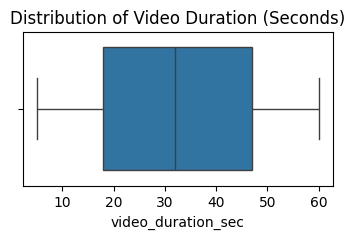

In [18]:
### YOUR CODE HERE ###
plt.figure(figsize = (4,2))

sns.boxplot(x = 'video_duration_sec', data = data_subset) 

plt.title('Distribution of Video Duration (Seconds)') 
plt.show() 

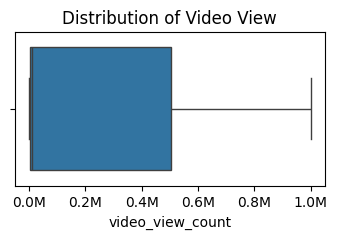

In [22]:
plt.figure(figsize = (4,2))

sns.boxplot(x = 'video_view_count', data = data_subset) 


plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.title('Distribution of Video View') 
plt.show() 

Check class balance.

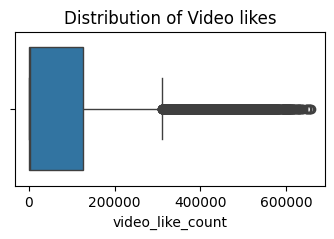

In [23]:
plt.figure(figsize = (4,2))

sns.boxplot(x = 'video_like_count', data = data_subset) 

plt.title('Distribution of Video likes') 
plt.show() 

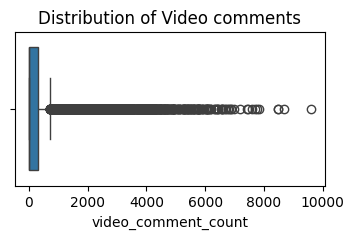

In [24]:
plt.figure(figsize = (4,2))

sns.boxplot(x = 'video_comment_count', data = data_subset) 

plt.title('Distribution of Video comments') 
plt.show() 

In [28]:
"""Handling these outliers carries certain risks for the following reasons: 
1. These outliers are not data error 
2. They reflect real viral behavior
3. Removing them could distort the true distriution"""

'Handling these outliers carries certain risks for the following reasons: \n1. These outliers are not data error \n2. They reflect real viral behavior\n3. Removing them could distort the true distriution'

In [29]:
data_subset['verified_status'].value_counts()

verified_status
not verified    17884
verified         1200
Name: count, dtype: int64

In [17]:
# Check class balance
### YOUR CODE HERE ###
data_subset['claim_status'].value_counts()

claim_status
claim      9608
opinion    9476
Name: count, dtype: int64

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**
Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3: Feature engineering**

Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [30]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
### YOUR CODE HERE ###
data_subset['text_length'] = data_subset['video_transcription_text'].apply(func=lambda text: len(text))

Calculate the average text_length for claims and opinions.

In [36]:
# Calculate the average text_length for claims and opinions
### YOUR CODE HERE ###
data_subset.groupby('claim_status').agg({'text_length': 'mean'}).rename(columns = {'text_length': 'Avg. Text length'})

,Avg. Text length
claim_status,
claim,95.376978
opinion,82.722562


Visualize the distribution of `text_length` for claims and opinions.

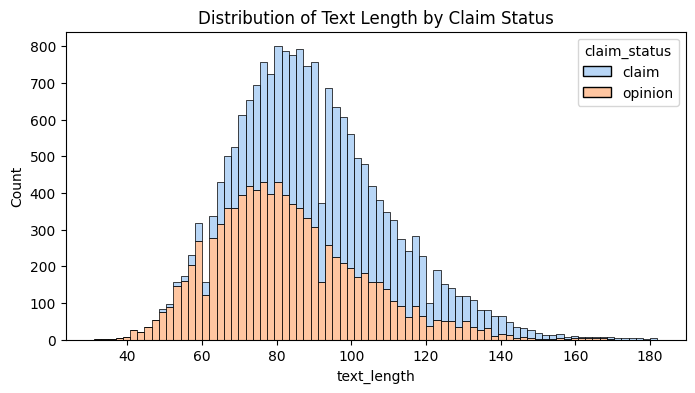

In [68]:
# Visualize the distribution of `text_length` for claims and opinions
# Create two histograms in one plot
### YOUR CODE HERE ###

plt.figure(figsize = (8,4))
sns.histplot(x = 'text_length', data = data_subset, multiple = 'stack',  palette='pastel', hue = 'claim_status', legend = True) )
plt.title('Distribution of Text Length by Claim Status') 
plt.show() 

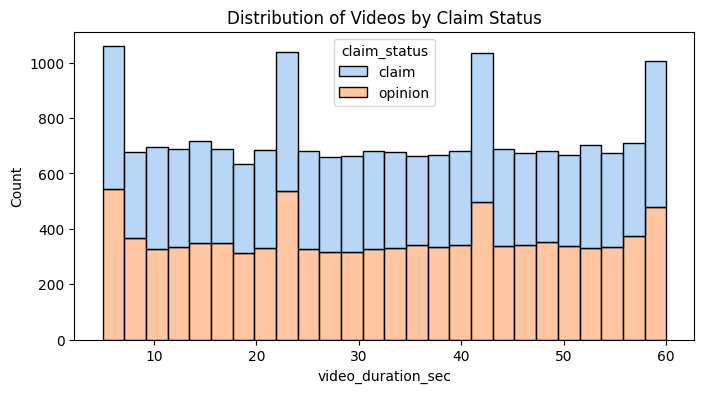

In [70]:
plt.figure(figsize = (8,4))
sns.histplot(x = 'video_duration_sec', data = data_subset, multiple = 'stack',  palette='pastel', hue = 'claim_status', legend = True) 

plt.title('Distribution of Videos by Claim Status') 
plt.show() 

**Feature selection and transformation**

Encode target and catgorical variables.

In [56]:
# Create a copy of the X data
### YOUR CODE HERE ###
X_before = data_subset.drop(columns = ['claim_status'])

# Drop unnecessary columns
### YOUR CODE HERE ###
X_before = X_before.drop(columns = ['#', 'video_id','video_transcription_text'])
# Encode target variable
### YOUR CODE HERE ###
X = pd.get_dummies(data = X_before, columns = ['verified_status', 'author_ban_status'], dtype=int)

In [57]:
X.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_not verified,verified_status_verified,author_ban_status_active,author_ban_status_banned,author_ban_status_under review
0,59,343296.0,19425.0,241.0,1.0,0.0,97,1,0,0,0,1
1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,1,0,1,0,0
2,31,902185.0,97690.0,2858.0,833.0,329.0,137,1,0,1,0,0
3,25,437506.0,239954.0,34812.0,1234.0,584.0,131,1,0,1,0,0
4,19,56167.0,34987.0,4110.0,547.0,152.0,128,1,0,1,0,0


### **Task 4: Split the data**

Assign target variable.

In [66]:
# Isolate target variable
### YOUR CODE HERE ###
y = data_subset['claim_status']
y = y.map({'claim': 1, 'opinion':0})
y

0        1
1        1
2        1
3        1
4        1
        ..
19079    0
19080    0
19081    0
19082    0
19083    0
Name: claim_status, Length: 19084, dtype: int64

Isolate the features.

#### **Task 5: Create train/validate/test sets**

Split data into training and testing sets, 80/20.

In [71]:
# Split the data into training and testing sets
### YOUR CODE HERE ###
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, stratify = y, random_state = 42)

Split the training set into training and validation sets, 75/25, to result in a final ratio of 60/20/20 for train/validate/test sets.

In [72]:
# Split the training data into training and validation sets
### YOUR CODE HERE ###
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = 0.25, stratify = y_train, random_state = 41)

Confirm that the dimensions of the training, validation, and testing sets are in alignment.

In [74]:
# Get shape of each training, validation, and testing set
### YOUR CODE HERE ###
for i in [X_train, X_val, X_test, y_train, y_val, y_test]: 
    print(i.shape)

(15267, 12)
(3817, 12)
(3817, 12)
(15267,)
(3817,)
(3817,)


### **Task 6. Build models**


### **Build a random forest model**

Fit a random forest model to the training set. Use cross-validation to tune the hyperparameters and select the model that performs best on recall.

In [81]:
# Instantiate the random forest classifier
### YOUR CODE HERE ###
rf = RandomForestClassifier(random_state = 0)
# Create a dictionary of hyperparameters to tune
### YOUR CODE HERE ###
para = {'n_estimators':[75,100,150],
       'max_depth':[5,10, 50],
       'min_samples_leaf':[1, 2],
       'min_samples_split':[0.001, 0.01],
       'max_features':['sqrt'],
       'max_samples':[.5,.8]}

# Define a list of scoring metrics to capture
### YOUR CODE HERE ###
scoring = ['accuracy','recall','precision','f1']
# Instantiate the GridSearchCV object
### YOUR CODE HERE ###
rf_cv = GridSearchCV(rf, para, scoring = scoring, refit = 'recall', n_jobs = -1)

In [82]:
%%time
### Fit the model to the data 
### YOUR CODE HERE ###
rf_cv.fit(X_train, y_train)

CPU times: user 1.9 s, sys: 423 ms, total: 2.32 s
Wall time: 2min 38s


GridSearchCV(estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 50], 'max_features': ['sqrt'],
                         'max_samples': [0.5, 0.8], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [0.001, 0.01],
                         'n_estimators': [75, 100, 150]},
             refit='recall', scoring=['accuracy', 'recall', 'precision', 'f1'])

In [83]:
# Examine best recall score
### YOUR CODE HERE ###
print(rf_cv.best_score_)

0.9899819197548464


In [84]:
# Examine best parameters
### YOUR CODE HERE ###
print(rf_cv.best_params_)

{'max_depth': 10, 'max_features': 'sqrt', 'max_samples': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 0.001, 'n_estimators': 100}


Check the precision score to make sure the model isn't labeling everything as claims. You can do this by using the `cv_results_` attribute of the fit `GridSearchCV` object, which returns a numpy array that can be converted to a pandas dataframe. Then, examine the `mean_test_precision` column of this dataframe at the index containing the results from the best model. This index can be accessed by using the `best_index_` attribute of the fit `GridSearchCV` object.

In [85]:
# Access the GridSearch results and convert it to a pandas df
### YOUR CODE HERE ###

# Examine the GridSearch results df at column `mean_test_precision` in the best index
### YOUR CODE HERE ###

def make_results(model_name, model_object):
    '''
    Accepts as arguments a model name (your choice - string) and
    a fit GridSearchCV model object.
  
    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean F1 score across all validation folds.  
    '''

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(mean f1 score)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_recall'].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                          'F1': [f1],
                          'Recall': [recall],
                          'Precision': [precision],
                          'Accuracy': [accuracy]
                         }
                        )
  
    return table

**Question:** How well is your model performing? Consider average recall score and precision score.

In [87]:
make_results('RF_cv_model', rf_cv)

,Model,F1,Recall,Precision,Accuracy
0,RF_cv_model,0.99477,0.989982,0.999606,0.99476


### **Build an XGBoost model**

In [88]:
# Instantiate the XGBoost classifier
### YOUR CODE HERE ###
xgb = XGBClassifier(objective = 'binary:logistic', random_state = 1)
# Create a dictionary of hyperparameters to tune
### YOUR CODE HERE ###
para_1 = {'max_depth': [4, 6],
              'min_child_weight': [3, 5],
              'learning_rate': [0.1, 0.2, 0.3],
              'n_estimators': [5,10,15],
              'subsample': [0.7],
              'colsample_bytree': [0.7]}
# Define a list of scoring metrics to capture
### YOUR CODE HERE ###
# Instantiate the GridSearchCV object
### YOUR CODE HERE ###
xgb_cv = GridSearchCV(xgb, para_1, scoring = scoring, refit = 'recall', n_jobs = -1)

In [89]:
%%time

# Fit the model to the data
### YOUR CODE HERE ###
xgb_cv.fit(X_train, y_train)

CPU times: user 326 ms, sys: 134 ms, total: 460 ms
Wall time: 6.57 s


GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_b...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=1, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7],
                         'learning_rate': [0.1, 0.2, 0.3], 'max_depth': [4, 6],
                         'min_child_weight': [3, 5],
                         'n_estimators': [5, 10, 15], 'subsample': [0.7]},
             refit='recall', scoring=['accuracy', 'recall', 'precision', 'f1'])

In [90]:
# Examine best recall score
### YOUR CODE HERE ###
print(xgb_cv.best_score_)

0.9886808527919468


In [91]:
# Examine best parameters
### YOUR CODE HERE ###
print(xgb_cv.best_params_)

{'colsample_bytree': 0.7, 'learning_rate': 0.3, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 15, 'subsample': 0.7}


Repeat the steps used for random forest to examine the precision score of the best model identified in the grid search.

In [92]:
# Access the GridSearch results and convert it to a pandas df
### YOUR CODE HERE ###

# Examine the GridSearch results df at column `mean_test_precision` in the best index
### YOUR CODE HERE ###
make_results('XGB_cv_model', xgb_cv)

,Model,F1,Recall,Precision,Accuracy
0,XGB_cv_model,0.993983,0.988681,0.999343,0.993974


**Question:** How well does your model perform? Consider recall score and precision score.

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**
Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 7. Evaluate model**

Evaluate models against validation criteria.

#### **Random forest**

In [97]:
# Use the random forest "best estimator" model to get predictions on the validation set
### YOUR CODE HERE ###
rf_cv_best = RandomForestClassifier(**rf_cv.best_params_, random_state = 3)

In [98]:
rf_cv_best.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_samples=0.5, min_samples_split=0.001,
                       random_state=3)

Display the predictions on the validation set.

In [99]:
# Display the predictions on the validation set
### YOUR CODE HERE ###
y_pred_val_rf = rf_cv_best.predict(X_val)

Display the true labels of the validation set.

In [100]:
# Display the true labels of the validation set
### YOUR CODE HERE ###
y_val

2747     1
16725    0
17303    0
7203     1
15194    0
        ..
7964     1
8357     1
18036    0
391      1
8173     1
Name: claim_status, Length: 3817, dtype: int64

Create a confusion matrix to visualize the results of the classification model.

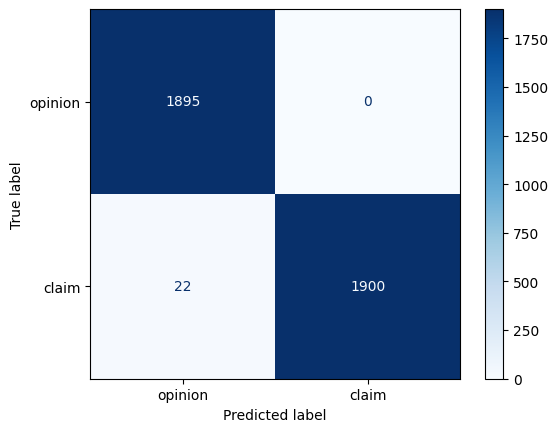

In [101]:
cm = confusion_matrix(y_val, y_pred_val_rf)

# Create display of confusion matrix
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['opinion', 'claim'])

# Plot confusion matrix
cm_disp.plot(cmap='Blues', values_format = '')

# Display plot
plt.show()


Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the model.
<br> </br>

**Note:** In other labs there was a custom-written function to extract the accuracy, precision, recall, and F<sub>1</sub> scores from the GridSearchCV report and display them in a table. You can also use scikit-learn's built-in [`classification_report()`](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-report) function to obtain a similar table of results.

In [104]:
# Create a classification report
# Create classification report for random forest model
### YOUR CODE HERE ###
print(classification_report(y_val, y_pred_val_rf, target_names=['option', 'claim']))

              precision    recall  f1-score   support

      option       0.99      1.00      0.99      1895
       claim       1.00      0.99      0.99      1922

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



**Question:** What does your classification report show? What does the confusion matrix indicate?

#### **XGBoost**

Now, evaluate the XGBoost model on the validation set.

In [107]:
# Use the best estimator to predict on the validation data
### YOUR CODE HERE ###
xgb_cv_best = XGBClassifier(**xgb_cv.best_params_, random_state = 4)


In [108]:
xgb_cv_best.fit(X_train, y_train )

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=15, n_jobs=None,
              num_parallel_tree=None, random_state=4, ...)

In [109]:
y_pred_val_xgb = xgb_cv_best.predict(X_val)

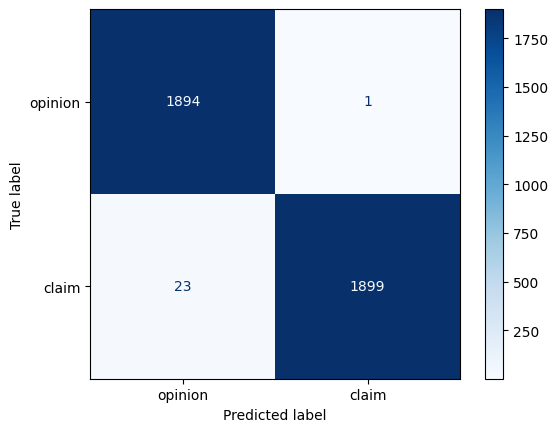

In [110]:
# Compute values for confusion matrix
cm = confusion_matrix(y_val, y_pred_val_xgb)

# Create display of confusion matrix
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['opinion', 'claim'])

# Plot confusion matrix
cm_disp.plot(cmap='Blues', values_format = '')

# Display plot
plt.show()


In [111]:
# Create a classification report
### YOUR CODE HERE ###
print(classification_report(y_val, y_pred_val_xgb, target_names=['option', 'claim']))

              precision    recall  f1-score   support

      option       0.99      1.00      0.99      1895
       claim       1.00      0.99      0.99      1922

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



**Question:** Describe your XGBoost model results. How does your XGBoost model compare to your random forest model?

### **Use champion model to predict on test data**

In [112]:
### YOUR CODE HERE ###
y_pred_final = rf_cv_best.predict(X_test) 

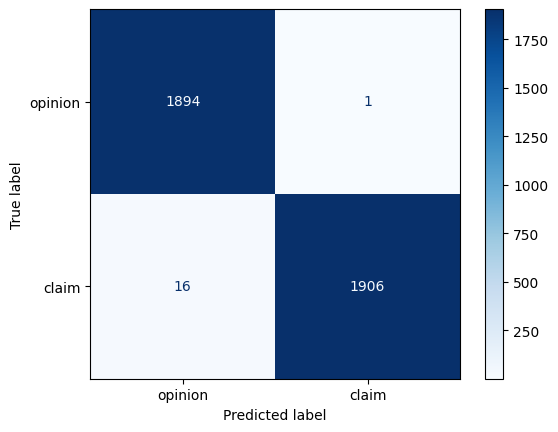

In [113]:
# Compute values for confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
# Create display of confusion matrix
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['opinion', 'claim'])

# Plot confusion matrix
cm_disp.plot(cmap='Blues', values_format = '')

# Display plot
plt.show()


#### **Feature importances of champion model**


In [115]:
### YOUR CODE HERE ###
feature_importance = pd.Series(rf_cv_best.feature_importances_, index = X.columns).sort_values(ascending = False)


video_like_count                  0.269964
video_share_count                 0.240341
video_view_count                  0.203401
video_download_count              0.168148
video_comment_count               0.103179
author_ban_status_active          0.006108
text_length                       0.005299
author_ban_status_banned          0.001569
author_ban_status_under review    0.000922
video_duration_sec                0.000638
verified_status_not verified      0.000403
verified_status_verified          0.000029
dtype: float64

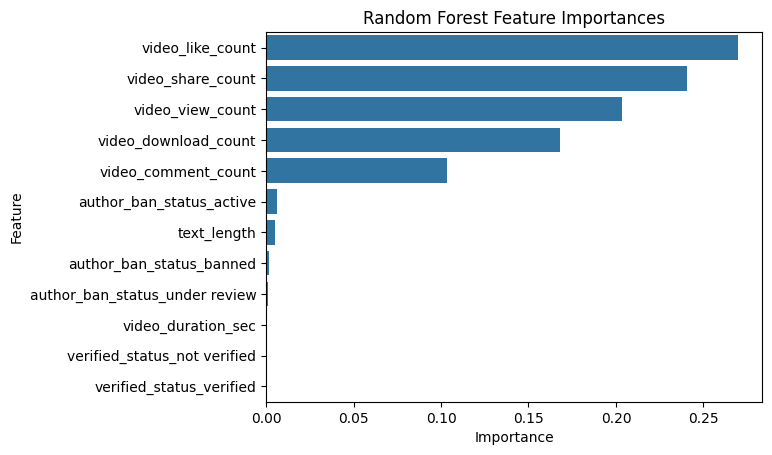

In [116]:
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Question:** Describe your most predictive features. Were your results surprising?

### **Task 8. Conclusion**

In this step use the results of the models above to formulate a conclusion. Consider the following questions:

1. **Would you recommend using this model? Why or why not?**
Yes. Confusion metrics and the classification report on test data show that the final random forest model achieves 99 percent accuracy, recall, precision, and F1 score, indicating strong predictive power for classifying whether videos are claims or opinions on new data. 
2. **What was your model doing? Can you explain how it was making predictions?**
The champion model is a Random Forest that makes predictions by combining 100 decision trees (n_estimators=100) through majority voting.
Key modeling choices:
Each tree used a random square root of total features (max_features='sqrt') to ensure diversity between trees
Trees were limited to depth 10 (max_depth=10) to prevent overfitting
Each tree trained on 50% of the data (max_samples=0.5) for further diversity
3. **Are there new features that you can engineer that might improve model performance?**
The number of reports can be a meaningful feature to improve model performance.
4. **What features would you want to have that would likely improve the performance of your model?**
Feature importances show that the user-verified status is not significantly associated with video classification. This is contradicted by the fact that we found there was a noteworthy difference between verified and unverified users in video classification, so we would be likely to improve this model's performance by engineering the column.


Remember, sometimes your data simply will not be predictive of your chosen target. This is common. Machine learning is a powerful tool, but it is not magic. If your data does not contain predictive signal, even the most complex algorithm will not be able to deliver consistent and accurate predictions. Do not be afraid to draw this conclusion.


==> ENTER YOUR RESPONSES HERE

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.